60000 train samples
10000 test samples


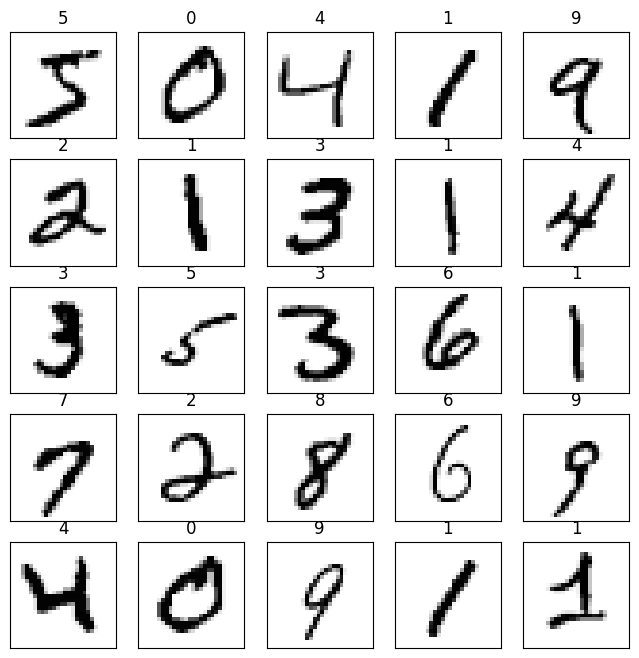

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8721 - loss: 0.4130 - val_accuracy: 0.9705 - val_loss: 0.0938
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9721 - loss: 0.0887 - val_accuracy: 0.9647 - val_loss: 0.1111
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9833 - loss: 0.0539 - val_accuracy: 0.9745 - val_loss: 0.0773
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9887 - loss: 0.0376 - val_accuracy: 0.9804 - val_loss: 0.0743
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9922 - loss: 0.0256 - val_accuracy: 0.9820 - val_loss: 0.0667
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9935 - loss: 0.0192 - val_accuracy: 0.9828 - val_loss: 0.0725
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9962 - loss: 0.0126 - val_accuracy: 0.9807 - val_loss: 0.0703
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9965 - loss: 0.0109 - val_ac

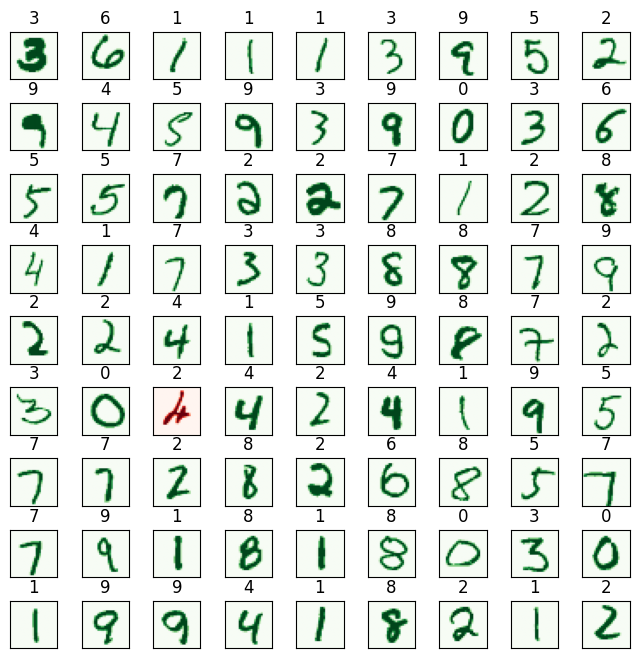

In [ ]:
import tensorflow
import ssl
import os
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import RMSprop

ssl._create_default_https_context = ssl._create_unverified_context
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

batch_size = 128
num_classes = 10
epochs = 10

# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = tensorflow.keras.utils.to_categorical(y_train, num_classes)
y_test = tensorflow.keras.utils.to_categorical(y_test, num_classes)

import numpy as np
import math

# How many numbers to display.
numbers_to_display = 25

# Calculate the number of cells that will hold all the numbers.
num_cells = math.ceil(math.sqrt(numbers_to_display))

# Make the plot a little bit bigger than default one.
plt.figure(figsize=(8, 8))

# Go through the first numbers in a training set and plot them.
for plot_index in range(numbers_to_display):
    # Extract digit data.
    digit = x_train[plot_index:plot_index + 1]
    digit_label = np.argmax(y_train[plot_index:plot_index + 1])

    frame = digit[0].reshape(28,28)

    # Plot the number matrix.
    plt.subplot(num_cells, num_cells, plot_index + 1)
    plt.imshow(frame, cmap='Greys')
    plt.title(digit_label)
    plt.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

plt.show()

model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))
#model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

model.summary()

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

# Out-ofSample Prediction Accuracy
train_score = model.evaluate(x_train, y_train, verbose=0)
test_score = model.evaluate(x_test, y_test, verbose=0)

print('Train accuracy:', train_score[1])
print('Test accuracy:', test_score[1])

y_pred = model.predict(x_test)

# How many numbers to display.
numbers_to_display = 81
start_idx = 200

# Calculate the number of cells that will hold all the numbers.
num_cells = math.ceil(math.sqrt(numbers_to_display))

# Make the plot a little bit bigger than default one.
plt.figure(figsize=(8, 8))

# Go through the first numbers in a test set and plot them.
for plot_index in range(numbers_to_display):
    # Extract digit data.
    digit_label = np.argmax(y_test[start_idx+plot_index])
    digit_pixels = x_test[start_idx+plot_index, :]

    # Predicted label.
    predicted_label = np.argmax(y_pred[start_idx+plot_index])

    # Calculate image size (remember that each picture has square proportions).
    image_size = int(math.sqrt(digit_pixels.shape[0]))

    # Convert image vector into the matrix of pixels.
    frame = digit_pixels.reshape((image_size, image_size))

    # Plot the number matrix.
    color_map = 'Greens' if predicted_label == digit_label else 'Reds'
    plt.subplot(num_cells, num_cells, plot_index + 1)
    plt.imshow(frame, cmap=color_map)
    plt.title(predicted_label)
    plt.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# Plot all subplots.
plt.subplots_adjust(hspace=0.5, wspace=0.5)

plt.show()

In [12]:
#Add more neurons in hidden layer (from 512 to 2048)
model = Sequential()
model.add(Dense(2048, activation='relu', input_shape=(784,)))
#model.add(Dropout(0.2))
model.add(Dense(2048, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

model.summary()

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

# Out-ofSample Prediction Accuracy
train_score = model.evaluate(x_train, y_train, verbose=0)
test_score = model.evaluate(x_test, y_test, verbose=0)

print('Train accuracy:', train_score[1])
print('Test accuracy:', test_score[1])


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 2048)           │     1,607,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,824,522 (22.22 MB)

 Trainable params: 5,824,522 (22.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 165ms/step - accuracy: 0.8711 - loss: 0.4107 - val_accuracy: 0.9686 - val_loss: 0.0984
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accuracy: 0.9759 - loss: 0.0744 - val_accuracy: 0.9747 - val_loss: 0.0781
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 158ms/step - accuracy: 0.9858 - loss: 0.0426 - val_accuracy: 0.9775 - val_loss: 0.0765
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 163ms/step - accuracy: 0.9903 - loss: 0.0297 - val_accuracy: 0.9834 - val_loss: 0.0623
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 164ms/step - accuracy: 0.9929 - loss: 0.0213 - val_accuracy: 0.9823 - val_loss: 0.0704
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accuracy: 0.9951 - loss: 0.0160 - val_accuracy: 0.9828 - val_loss: 0.0697
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 158ms/step - accuracy: 0.9966 - loss: 0.0107 - val_accuracy: 0.9839 - val_loss: 0.0642
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 159ms/step - accuracy: 0.9973 - loss: 0

In [ ]:
#Add one more hidden layer
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))
#model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

model.summary()

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

# Out-ofSample Prediction Accuracy
train_score = model.evaluate(x_train, y_train, verbose=0)
test_score = model.evaluate(x_test, y_test, verbose=0)

print('Train accuracy:', train_score[1])
print('Test accuracy:', test_score[1])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 932,362 (3.56 MB)

 Trainable params: 932,362 (3.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8475 - loss: 0.4676 - val_accuracy: 0.9699 - val_loss: 0.0965
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9734 - loss: 0.0894 - val_accuracy: 0.9653 - val_loss: 0.1145
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9815 - loss: 0.0582 - val_accuracy: 0.9793 - val_loss: 0.0697
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9878 - loss: 0.0394 - val_accuracy: 0.9788 - val_loss: 0.0771
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9909 - loss: 0.0283 - val_accuracy: 0.9833 - val_loss: 0.0677
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9939 - loss: 0.0197 - val_accuracy: 0.9795 - val_loss: 0.0900
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9941 - loss: 0.0184 - val_accuracy: 0.9811 - val_loss: 0.0832
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9960 - loss: 0.0133 - 

In [14]:
#More iterations
batch_size = 128
num_classes = 10
epochs = 25

model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))
#model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

model.summary()

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

# Out-ofSample Prediction Accuracy
train_score = model.evaluate(x_train, y_train, verbose=0)
test_score = model.evaluate(x_test, y_test, verbose=0)

print('Train accuracy:', train_score[1])
print('Test accuracy:', test_score[1])

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8667 - loss: 0.4191 - val_accuracy: 0.9641 - val_loss: 0.1131
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9723 - loss: 0.0910 - val_accuracy: 0.9697 - val_loss: 0.0961
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9835 - loss: 0.0522 - val_accuracy: 0.9797 - val_loss: 0.0645
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9879 - loss: 0.0367 - val_accuracy: 0.9833 - val_loss: 0.0597
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9912 - loss: 0.0276 - val_accuracy: 0.9824 - val_loss: 0.0666
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9940 - loss: 0.0180 - val_accuracy: 0.9823 - val_loss: 0.0655
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9953 - loss: 0.0145 - val_accuracy: 0.9815 - val_loss: 0.0766
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9966 - loss: 0.0109 - val_accu

In [17]:
#Learning rate = 0.01
batch_size = 128
num_classes = 10
epochs = 10

model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))
#model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(learning_rate=0.01),
              metrics=['accuracy'])

model.summary()

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

# Out-ofSample Prediction Accuracy
train_score = model.evaluate(x_train, y_train, verbose=0)
test_score = model.evaluate(x_test, y_test, verbose=0)

print('Train accuracy:', train_score[1])
print('Test accuracy:', test_score[1])

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8190 - loss: 1.4284 - val_accuracy: 0.9614 - val_loss: 0.1459
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9578 - loss: 0.1571 - val_accuracy: 0.9656 - val_loss: 0.1348
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9644 - loss: 0.1384 - val_accuracy: 0.9688 - val_loss: 0.1423
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9689 - loss: 0.1287 - val_accuracy: 0.9549 - val_loss: 0.2194
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9736 - loss: 0.1102 - val_accuracy: 0.9639 - val_loss: 0.1925
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9749 - loss: 0.1115 - val_accuracy: 0.9641 - val_loss: 0.2104
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9770 - loss: 0.0998 - val_accuracy: 0.9660 - val_loss: 0.2136
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9788 - loss: 0.0986 - val_a

In [20]:
#Learning rate = 0.001
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))
#model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

model.summary()

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

# Out-ofSample Prediction Accuracy
train_score = model.evaluate(x_train, y_train, verbose=0)
test_score = model.evaluate(x_test, y_test, verbose=0)

print('Train accuracy:', train_score[1])
print('Test accuracy:', test_score[1])

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8712 - loss: 0.4174 - val_accuracy: 0.9635 - val_loss: 0.1138
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9716 - loss: 0.0907 - val_accuracy: 0.9781 - val_loss: 0.0710
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9830 - loss: 0.0526 - val_accuracy: 0.9736 - val_loss: 0.0778
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9891 - loss: 0.0344 - val_accuracy: 0.9785 - val_loss: 0.0765
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9800 - val_loss: 0.0707
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9938 - loss: 0.0200 - val_accuracy: 0.9809 - val_loss: 0.0672
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9958 - loss: 0.0129 - val_accuracy: 0.9803 - val_loss: 0.0852
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9960 - loss: 0.0116 - val_ac

In [19]:
#Learning rate = 0.0001
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))
#model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(learning_rate=0.0001),
              metrics=['accuracy'])

model.summary()

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

# Out-ofSample Prediction Accuracy
train_score = model.evaluate(x_train, y_train, verbose=0)
test_score = model.evaluate(x_test, y_test, verbose=0)

print('Train accuracy:', train_score[1])
print('Test accuracy:', test_score[1])

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7933 - loss: 0.8920 - val_accuracy: 0.9304 - val_loss: 0.2523
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9314 - loss: 0.2404 - val_accuracy: 0.9447 - val_loss: 0.1932
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9512 - loss: 0.1776 - val_accuracy: 0.9571 - val_loss: 0.1481
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9618 - loss: 0.1379 - val_accuracy: 0.9594 - val_loss: 0.1332
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9660 - loss: 0.1177 - val_accuracy: 0.9660 - val_loss: 0.1119
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9718 - loss: 0.0993 - val_accuracy: 0.9691 - val_loss: 0.1010
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9758 - loss: 0.0863 - val_accuracy: 0.9717 - val_loss: 0.0931
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9800 - loss: 0.0737 - val_ac

In [21]:
#Regularization parameter L1 L2
from tensorflow.keras.regularizers import l1_l2

model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,), kernel_regularizer=l1_l2(l1=0.001, l2=0.001)))
#model.add(Dropout(0.2))
model.add(Dense(512, activation='relu', kernel_regularizer=l1_l2(l1=0.001, l2=0.001)))
#model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

model.summary()

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

# Out-ofSample Prediction Accuracy
train_score = model.evaluate(x_train, y_train, verbose=0)
test_score = model.evaluate(x_test, y_test, verbose=0)

print('Train accuracy:', train_score[1])
print('Test accuracy:', test_score[1])


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_58 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.7987 - loss: 6.8370 - val_accuracy: 0.9107 - val_loss: 1.0097
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9068 - loss: 0.9831 - val_accuracy: 0.9130 - val_loss: 0.8782
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9201 - loss: 0.8520 - val_accuracy: 0.9331 - val_loss: 0.7939
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9282 - loss: 0.7983 - val_accuracy: 0.9232 - val_loss: 0.7843
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9280 - loss: 0.7723 - val_accuracy: 0.9330 - val_loss: 0.7537
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9369 - loss: 0.7425 - val_accuracy: 0.9409 - val_loss: 0.7213
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9348 - loss: 0.7356 - val_accuracy: 0.9407 - val_loss: 0.7077
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9351 - loss: 0.7241 - va

In [22]:
#Activation function tanh
model = Sequential()
model.add(Dense(512, activation='tanh', input_shape=(784,)))
#model.add(Dropout(0.2))
model.add(Dense(512, activation='tanh'))
#model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

model.summary()

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

# Out-ofSample Prediction Accuracy
train_score = model.evaluate(x_train, y_train, verbose=0)
test_score = model.evaluate(x_test, y_test, verbose=0)

print('Train accuracy:', train_score[1])
print('Test accuracy:', test_score[1])

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_61 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8473 - loss: 0.5007 - val_accuracy: 0.9404 - val_loss: 0.2029
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9565 - loss: 0.1431 - val_accuracy: 0.9607 - val_loss: 0.1206
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9743 - loss: 0.0824 - val_accuracy: 0.9634 - val_loss: 0.1175
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9817 - loss: 0.0594 - val_accuracy: 0.9742 - val_loss: 0.0779
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9878 - loss: 0.0401 - val_accuracy: 0.9770 - val_loss: 0.0710
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9915 - loss: 0.0280 - val_accuracy: 0.9757 - val_loss: 0.0763
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9943 - loss: 0.0196 - val_accuracy: 0.9784 - val_loss: 0.0631
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9970 - loss: 0.0123 - val_ac

In [23]:
#Activation function sigmoid
model = Sequential()
model.add(Dense(512, activation='sigmoid', input_shape=(784,)))
#model.add(Dropout(0.2))
model.add(Dense(512, activation='sigmoid'))
#model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

model.summary()

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

# Out-ofSample Prediction Accuracy
train_score = model.evaluate(x_train, y_train, verbose=0)
test_score = model.evaluate(x_test, y_test, verbose=0)

print('Train accuracy:', train_score[1])
print('Test accuracy:', test_score[1])

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.6769 - loss: 1.0330 - val_accuracy: 0.9124 - val_loss: 0.2924
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9166 - loss: 0.2776 - val_accuracy: 0.9275 - val_loss: 0.2326
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9384 - loss: 0.2073 - val_accuracy: 0.9486 - val_loss: 0.1650
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9502 - loss: 0.1656 - val_accuracy: 0.9525 - val_loss: 0.1529
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9617 - loss: 0.1280 - val_accuracy: 0.9614 - val_loss: 0.1202
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9685 - loss: 0.1081 - val_accuracy: 0.9646 - val_loss: 0.1131
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9730 - loss: 0.0901 - val_accuracy: 0.9694 - val_loss: 0.0944
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9770 - loss: 0.0755 - val_acc

In [24]:
import pandas as pd

# Create results summary
results_data = {
    'Model Configuration': [
        'Normal (2x512 relu)',
        'More neurons (2x2048 relu)',
        'Extra hidden layer (3x512 relu)',
        'More iterations (25 epochs)',
        'Learning rate 0.01',
        'Learning rate 0.001',
        'Learning rate 0.0001',
        'Regularization L1L2',
        'Activation tanh',
        'Activation sigmoid'
    ],
    'Train Accuracy': [
        99.84,
        99.88,
        99.76,
        100.00,
        98.29,
        99.77,
        98.76,
        93.24,
        99.96,
        98.47
    ],
    'Test Accuracy': [
        98.32,
        98.47,
        98.23,
        98.74,
        96.94,
        98.05,
        97.68,
        93.44,
        98.16,
        97.56
    ],
    'Gap (Train-Test)': [
        1.52,
        1.41,
        1.53,
        1.26,
        1.35,
        1.72,
        1.08,
        -0.20,
        1.80,
        0.91
    ]
}

# Create DataFrame
results_df = pd.DataFrame(results_data)

# Display table
print("="*70)
print("EXPERIMENTAL RESULTS SUMMARY - MNIST CLASSIFICATION")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# Best performances
best_test = results_df.loc[results_df['Test Accuracy'].idxmax()]
print(f"\nBEST PERFORMANCES:")
print(f"Highest Test Accuracy: {best_test['Model Configuration']} - {best_test['Test Accuracy']}%")
print(f"Best Balanced Model: Normal (2x512 relu) - Test: 98.32%, Gap: 1.52%")

EXPERIMENTAL RESULTS SUMMARY - MNIST CLASSIFICATION
            Model Configuration  Train Accuracy  Test Accuracy  Gap (Train-Test)
            Normal (2x512 relu)           99.84          98.32              1.52
     More neurons (2x2048 relu)           99.88          98.47              1.41
Extra hidden layer (3x512 relu)           99.76          98.23              1.53
    More iterations (25 epochs)          100.00          98.74              1.26
             Learning rate 0.01           98.29          96.94              1.35
            Learning rate 0.001           99.77          98.05              1.72
           Learning rate 0.0001           98.76          97.68              1.08
            Regularization L1L2           93.24          93.44             -0.20
                Activation tanh           99.96          98.16              1.80
             Activation sigmoid           98.47          97.56              0.91

BEST PERFORMANCES:
Highest Test Accuracy: More iteration